In [2]:
# ==============================================================================
# COMPARACIÓN DE MODELOS: GAM vs LightGBM
# Predicción de Attrition (fuga) de clientes bancarios
# Dataset: train_clientes.csv (Caso BBVA)
# Para ejecutar en: Google Colab
# ==============================================================================

# ==============================================================================
# BLOQUE 0 — INSTALACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
# Se instalan las librerías que no vienen por defecto en Colab.
# pygam: implementación de GAM (Generalized Additive Models).
# lightgbm: gradient boosting optimizado para grandes datasets.
# shap: valores SHAP para interpretabilidad de modelos.
# imbalanced-learn: SMOTE para balanceo de clases.
# ==============================================================================

!pip install pygam lightgbm shap imbalanced-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.7 MB/s eta 0:00:00


In [3]:


# ==============================================================================
# BLOQUE 1 — IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
# Cargamos todas las librerías necesarias para el pipeline completo:
# preprocesamiento, modelado, evaluación y visualización.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# Modelo GAM
from pygam import LogisticGAM, s, f

# Modelo LightGBM
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Interpretabilidad
import shap

print("✅ Librerías cargadas correctamente.")



✅ Librerías cargadas correctamente.


In [4]:

from google.colab import files
uploaded = files.upload()   # selecciona train_clientes.csv

Saving train_clientes.csv to train_clientes.csv


In [5]:

# ==============================================================================
# BLOQUE 2 — CARGA DE DATOS
# ------------------------------------------------------------------------------
# Leemos el CSV con separador punto y coma (;).
# El dataset tiene 70,000 registros y 53 variables.
# La variable target es ATTRITION (1 = fuga, 0 = no fuga).
# Subida del archivo: en Google Colab usar la celda de abajo para subir el CSV.
# ==============================================================================

# --- En Google Colab: descomentar y ejecutar para subir el archivo ---
# from google.colab import files
# uploaded = files.upload()   # selecciona train_clientes.csv

# Lectura del archivo (ajusta la ruta si subiste el archivo con el método anterior)
df = pd.read_csv("train_clientes.csv", sep=";")

# Vista rápida de la estructura
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nDistribución del target ATTRITION:")
print(df['ATTRITION'].value_counts())
print(f"\nTasa de attrition: {df['ATTRITION'].mean()*100:.1f}%")
print(f"\nTipos de variables:\n{df.dtypes.value_counts()}")



Dimensiones del dataset: (70000, 53)

Distribución del target ATTRITION:
ATTRITION
0    59178
1    10822
Name: count, dtype: int64

Tasa de attrition: 15.5%

Tipos de variables:
int64      47
object      4
float64     2
Name: count, dtype: int64


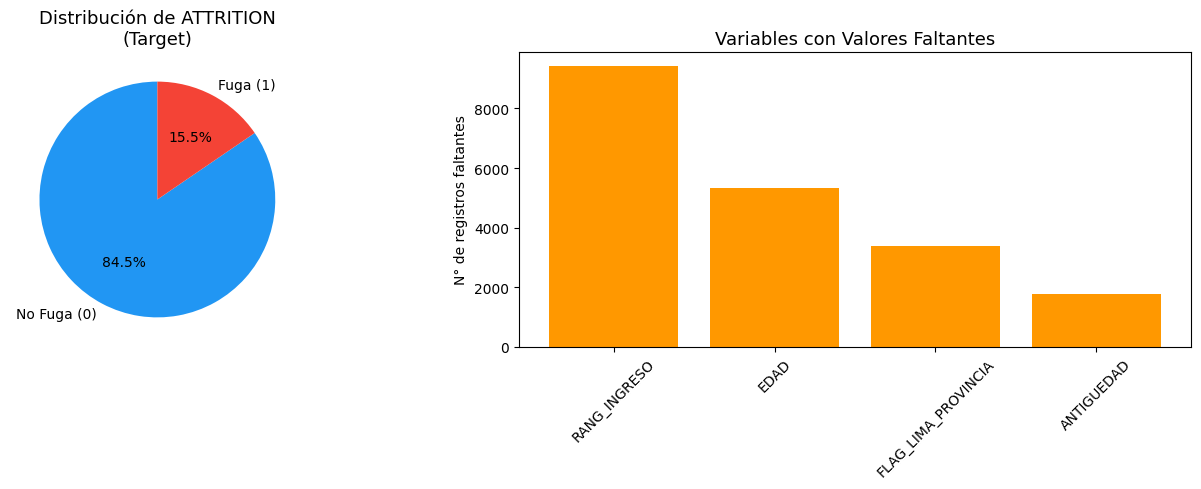

📊 Gráfico guardado: 01_eda_overview.png

✅ Grupos de variables con lags temporales identificados: ['SDO_ACTIVO', 'FLG_SEGURO', 'NRO_ACCES_CANAL1', 'NRO_ACCES_CANAL2', 'NRO_ACCES_CANAL3', 'NRO_ENTID_SSFF', 'FLG_SDO_OTSSFF']


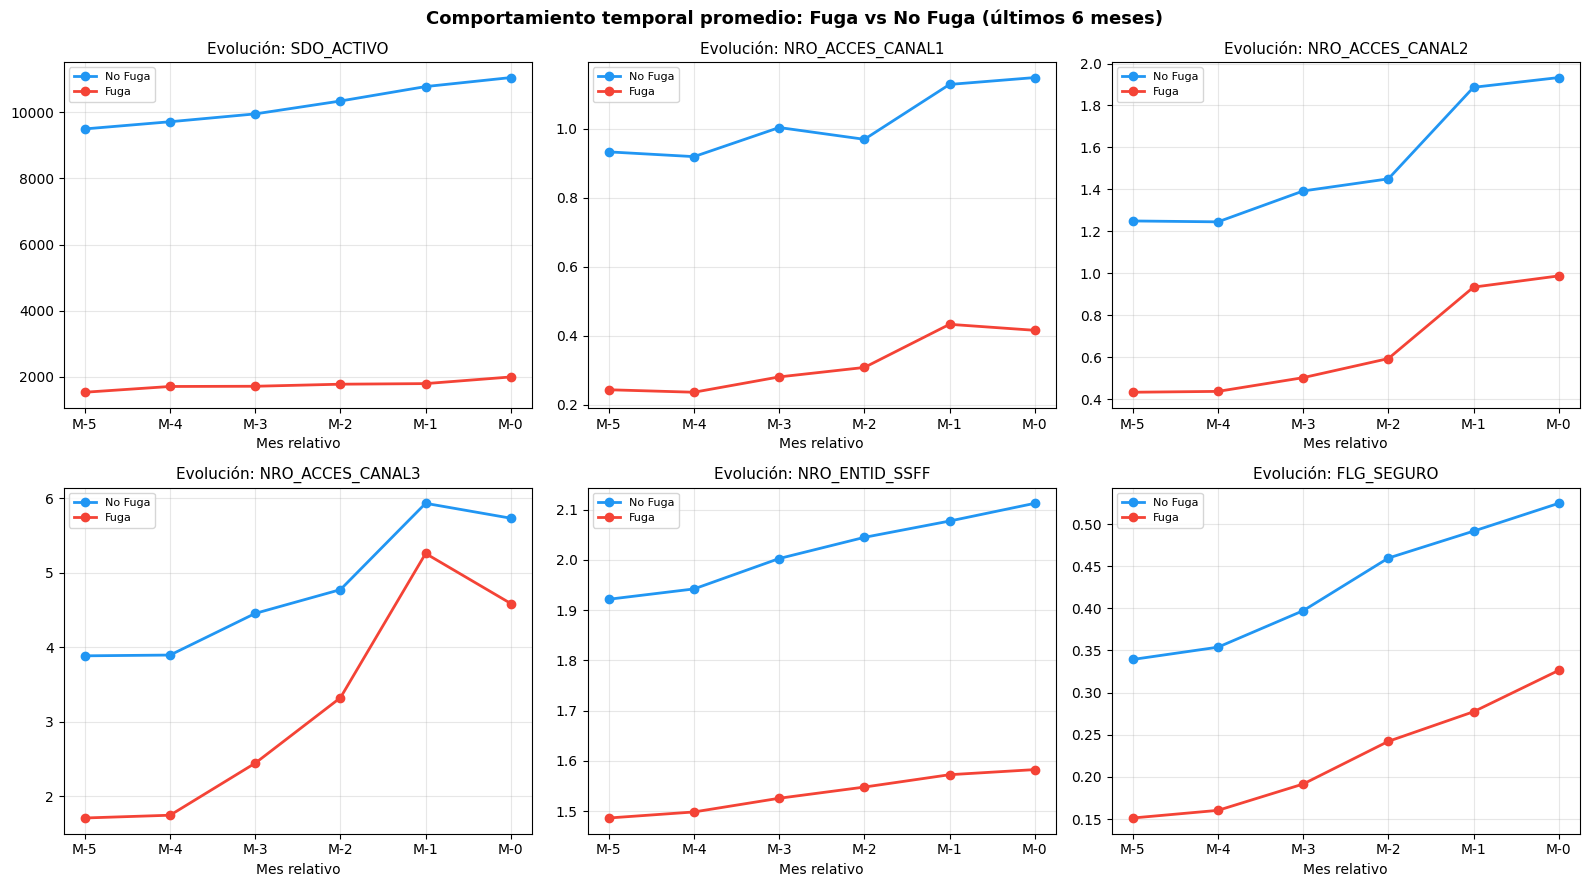

📊 Gráfico guardado: 02_evolucion_temporal.png


In [7]:

# ==============================================================================
# BLOQUE 3 — ANÁLISIS EXPLORATORIO (EDA)
# ------------------------------------------------------------------------------
# Revisamos la distribución del target, valores faltantes y la estructura
# de las variables, con especial atención a las series temporales (lags).
# Las variables con sufijo _MENOS0 a _MENOS5 corresponden a los últimos 6 meses.
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del target
attrition_counts = df['ATTRITION'].value_counts()
axes[0].pie(attrition_counts, labels=['No Fuga (0)', 'Fuga (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[0].set_title('Distribución de ATTRITION\n(Target)', fontsize=13)

# Valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
axes[1].bar(missing.index, missing.values, color='#FF9800')
axes[1].set_title('Variables con Valores Faltantes', fontsize=13)
axes[1].set_ylabel('N° de registros faltantes')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("01_eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 01_eda_overview.png")

# Identificar grupos de variables temporales (lags)
lag_groups = {
    'SDO_ACTIVO': [f'SDO_ACTIVO_MENOS{i}' for i in range(6)],
    'FLG_SEGURO': [f'FLG_SEGURO_MENOS{i}' for i in range(6)],
    'NRO_ACCES_CANAL1': [f'NRO_ACCES_CANAL1_MENOS{i}' for i in range(6)],
    'NRO_ACCES_CANAL2': [f'NRO_ACCES_CANAL2_MENOS{i}' for i in range(6)],
    'NRO_ACCES_CANAL3': [f'NRO_ACCES_CANAL3_MENOS{i}' for i in range(6)],
    'NRO_ENTID_SSFF': [f'NRO_ENTID_SSFF_MENOS{i}' for i in range(6)],
    'FLG_SDO_OTSSFF': [f'FLG_SDO_OTSSFF_MENOS{i}' for i in range(6)],
}
print(f"\n✅ Grupos de variables con lags temporales identificados: {list(lag_groups.keys())}")

# Evolución temporal promedio por grupo (para clientes con y sin fuga)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

temporal_vars_to_plot = ['SDO_ACTIVO', 'NRO_ACCES_CANAL1', 'NRO_ACCES_CANAL2',
                          'NRO_ACCES_CANAL3', 'NRO_ENTID_SSFF', 'FLG_SEGURO']

for idx, var in enumerate(temporal_vars_to_plot):
    cols = lag_groups[var]
    meses = [f'M-{i}' for i in range(5, -1, -1)]  # M-5 hasta M-0

    for label, color, name in [(0, '#2196F3', 'No Fuga'), (1, '#F44336', 'Fuga')]:
        valores = df[df['ATTRITION'] == label][cols].mean().values[::-1]
        axes[idx].plot(meses, valores, marker='o', color=color, label=name, linewidth=2)

    axes[idx].set_title(f'Evolución: {var}', fontsize=11)
    axes[idx].set_xlabel('Mes relativo')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Comportamiento temporal promedio: Fuga vs No Fuga (últimos 6 meses)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("02_evolucion_temporal.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 02_evolucion_temporal.png")



In [8]:

# ==============================================================================
# BLOQUE 4 — INGENIERÍA DE FEATURES TEMPORALES
# ------------------------------------------------------------------------------
# Aprovechando que tenemos 6 meses de historial para varias variables,
# construimos features que capturan:
#   - Tendencia: ¿está subiendo o bajando el saldo/actividad?
#   - Promedio: nivel medio de actividad en el periodo
#   - Variabilidad (std): estabilidad del comportamiento
#   - Última vs primera diferencia: cambio entre el mes más antiguo y el actual
# Estas features son más informativas que los lags individuales para el GAM,
# y complementan a LightGBM que puede aprender los patrones directamente.
# ==============================================================================

df_feat = df.copy()

for var, cols in lag_groups.items():
    # Orden cronológico: cols[5] es M-5 (más antiguo), cols[0] es M-0 (más reciente)
    cols_chron = cols[::-1]  # [MENOS5, MENOS4, ..., MENOS0]

    # Promedio de los últimos 6 meses
    df_feat[f'{var}_PROM6M'] = df[cols].mean(axis=1)

    # Desviación estándar: variabilidad en el periodo
    df_feat[f'{var}_STD6M'] = df[cols].std(axis=1)

    # Tendencia lineal: coeficiente de regresión sobre los 6 puntos de tiempo
    # Un valor positivo indica crecimiento; negativo, declive.
    x = np.arange(6)
    slopes = []
    for _, row in df[cols_chron].iterrows():
        y = row.values.astype(float)
        if np.std(y) > 0:
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = 0.0
        slopes.append(slope)
    df_feat[f'{var}_TEND6M'] = slopes

    # Diferencia último - primero (cambio total en el periodo)
    df_feat[f'{var}_DELTA6M'] = df[cols[0]] - df[cols[5]]

    # Valor más reciente (mes 0) — ya existe como _MENOS0, pero lo renombramos
    df_feat[f'{var}_RECIENTE'] = df[cols[0]]

print("✅ Features temporales creadas:")
nuevas_features = [c for c in df_feat.columns if any(
    s in c for s in ['_PROM6M', '_STD6M', '_TEND6M', '_DELTA6M', '_RECIENTE']
)]
for f_name in nuevas_features:
    print(f"   {f_name}")
print(f"\nTotal nuevas features: {len(nuevas_features)}")



✅ Features temporales creadas:
   SDO_ACTIVO_PROM6M
   SDO_ACTIVO_STD6M
   SDO_ACTIVO_TEND6M
   SDO_ACTIVO_DELTA6M
   SDO_ACTIVO_RECIENTE
   FLG_SEGURO_PROM6M
   FLG_SEGURO_STD6M
   FLG_SEGURO_TEND6M
   FLG_SEGURO_DELTA6M
   FLG_SEGURO_RECIENTE
   NRO_ACCES_CANAL1_PROM6M
   NRO_ACCES_CANAL1_STD6M
   NRO_ACCES_CANAL1_TEND6M
   NRO_ACCES_CANAL1_DELTA6M
   NRO_ACCES_CANAL1_RECIENTE
   NRO_ACCES_CANAL2_PROM6M
   NRO_ACCES_CANAL2_STD6M
   NRO_ACCES_CANAL2_TEND6M
   NRO_ACCES_CANAL2_DELTA6M
   NRO_ACCES_CANAL2_RECIENTE
   NRO_ACCES_CANAL3_PROM6M
   NRO_ACCES_CANAL3_STD6M
   NRO_ACCES_CANAL3_TEND6M
   NRO_ACCES_CANAL3_DELTA6M
   NRO_ACCES_CANAL3_RECIENTE
   NRO_ENTID_SSFF_PROM6M
   NRO_ENTID_SSFF_STD6M
   NRO_ENTID_SSFF_TEND6M
   NRO_ENTID_SSFF_DELTA6M
   NRO_ENTID_SSFF_RECIENTE
   FLG_SDO_OTSSFF_PROM6M
   FLG_SDO_OTSSFF_STD6M
   FLG_SDO_OTSSFF_TEND6M
   FLG_SDO_OTSSFF_DELTA6M
   FLG_SDO_OTSSFF_RECIENTE

Total nuevas features: 35


In [9]:

# ==============================================================================
# BLOQUE 5 — PREPROCESAMIENTO
# ------------------------------------------------------------------------------
# 5.1 Imputación de valores faltantes:
#       - Variables numéricas: mediana (más robusta que la media ante outliers)
#       - Variables categóricas: moda
# 5.2 Codificación de variables categóricas con Label Encoding.
# 5.3 Selección de variables para el modelo (eliminamos IDs y CODMES como predictor).
# ==============================================================================

# --- 5.1 Imputación ---
# Variables con faltantes: RANG_INGRESO, FLAG_LIMA_PROVINCIA, EDAD, ANTIGUEDAD

# Categóricas: imputar con moda
for col in ['RANG_INGRESO', 'FLAG_LIMA_PROVINCIA']:
    moda = df_feat[col].mode()[0]
    df_feat[col].fillna(moda, inplace=True)
    print(f"   {col}: imputado con moda = '{moda}'")

# Numéricas: imputar con mediana
for col in ['EDAD', 'ANTIGUEDAD']:
    mediana = df_feat[col].median()
    df_feat[col].fillna(mediana, inplace=True)
    print(f"   {col}: imputado con mediana = {mediana}")

print(f"\n✅ Faltantes restantes: {df_feat.isnull().sum().sum()}")

# --- 5.2 Codificación ---
# Variables categóricas ordinales: usamos Label Encoding
# RANG_INGRESO ya tiene un orden implícito (rang_ingreso_01 < rang_ingreso_02...)
# Lo mismo para RANG_SDO_PASIVO_MENOS0 y RANG_NRO_PRODUCTOS_MENOS0

le = LabelEncoder()
cat_cols = ['RANG_INGRESO', 'FLAG_LIMA_PROVINCIA',
            'RANG_SDO_PASIVO_MENOS0', 'RANG_NRO_PRODUCTOS_MENOS0']

for col in cat_cols:
    df_feat[col] = le.fit_transform(df_feat[col].astype(str))
    print(f"   {col}: {df_feat[col].nunique()} categorías codificadas")

# --- 5.3 Definición de variables para el modelo ---
# Excluimos: ID, CODMES (partición temporal, no predictor), y target
cols_excluir = ['ID_CORRELATIVO', 'CODMES', 'ATTRITION']

# Podemos optar por incluir lags individuales O solo features agregadas
# Aquí incluimos ambas para que LightGBM elija, y restringimos el GAM
# (ver más adelante por qué)
X_all = df_feat.drop(columns=cols_excluir)
y = df_feat['ATTRITION']

print(f"\n✅ Dimensiones finales de X: {X_all.shape}")
print(f"   Variables predictoras: {X_all.columns.tolist()}")


   RANG_INGRESO: imputado con moda = 'Rang_ingreso_01'
   FLAG_LIMA_PROVINCIA: imputado con moda = 'Lima'
   EDAD: imputado con mediana = 32.0
   ANTIGUEDAD: imputado con mediana = 0.0

✅ Faltantes restantes: 0
   RANG_INGRESO: 9 categorías codificadas
   FLAG_LIMA_PROVINCIA: 2 categorías codificadas
   RANG_SDO_PASIVO_MENOS0: 15 categorías codificadas
   RANG_NRO_PRODUCTOS_MENOS0: 6 categorías codificadas

✅ Dimensiones finales de X: (70000, 85)
   Variables predictoras: ['FLG_BANCARIZADO', 'RANG_INGRESO', 'FLAG_LIMA_PROVINCIA', 'EDAD', 'ANTIGUEDAD', 'RANG_SDO_PASIVO_MENOS0', 'SDO_ACTIVO_MENOS0', 'SDO_ACTIVO_MENOS1', 'SDO_ACTIVO_MENOS2', 'SDO_ACTIVO_MENOS3', 'SDO_ACTIVO_MENOS4', 'SDO_ACTIVO_MENOS5', 'FLG_SEGURO_MENOS0', 'FLG_SEGURO_MENOS1', 'FLG_SEGURO_MENOS2', 'FLG_SEGURO_MENOS3', 'FLG_SEGURO_MENOS4', 'FLG_SEGURO_MENOS5', 'RANG_NRO_PRODUCTOS_MENOS0', 'FLG_NOMINA', 'NRO_ACCES_CANAL1_MENOS0', 'NRO_ACCES_CANAL1_MENOS1', 'NRO_ACCES_CANAL1_MENOS2', 'NRO_ACCES_CANAL1_MENOS3', 'NRO_ACCES_CA

In [10]:


# ==============================================================================
# BLOQUE 6 — TRAIN / TEST SPLIT
# ------------------------------------------------------------------------------
# División estratificada 70% entrenamiento / 30% prueba.
# La estratificación garantiza que ambos subconjuntos tengan la misma
# proporción de clientes fugados (~15%), evitando sesgo de muestreo.
# ==============================================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train_full.shape[0]} registros | Test: {X_test.shape[0]} registros")
print(f"Attrition en train: {y_train_full.mean()*100:.1f}%")
print(f"Attrition en test:  {y_test.mean()*100:.1f}%")


# ==============================================================================
# BLOQUE 7 — BALANCEO DE CLASES CON SMOTE
# ------------------------------------------------------------------------------
# La clase positiva (fuga) representa ~15% del total: hay desbalance moderado.
# Aplicamos SMOTE (Synthetic Minority Over-sampling Technique) solo sobre el
# conjunto de entrenamiento para generar ejemplos sintéticos de la clase
# minoritaria. NUNCA se aplica sobre el test set (preserva distribución real).
# ==============================================================================

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_full, y_train_full)

print(f"Antes de SMOTE — Clase 0: {y_train_full.value_counts()[0]}, Clase 1: {y_train_full.value_counts()[1]}")
print(f"Después de SMOTE — Clase 0: {(y_train_bal==0).sum()}, Clase 1: {(y_train_bal==1).sum()}")


# ==============================================================================
# BLOQUE 8 — ESCALADO (necesario para GAM)
# ------------------------------------------------------------------------------
# El GAM usa splines que son sensibles a la escala de las variables.
# Normalizamos con StandardScaler. LightGBM NO requiere escalado (es basado
# en árboles), pero para mantener consistencia usamos el mismo X_train_bal.
# ==============================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

# Convertimos a DataFrame para mantener nombres de columnas (útil para SHAP)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_all.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=X_all.columns)

print("✅ Escalado aplicado. Shape train:", X_train_scaled_df.shape)


Train: 49000 registros | Test: 21000 registros
Attrition en train: 15.5%
Attrition en test:  15.5%
Antes de SMOTE — Clase 0: 41425, Clase 1: 7575
Después de SMOTE — Clase 0: 41425, Clase 1: 41425
✅ Escalado aplicado. Shape train: (82850, 85)


In [11]:


# ==============================================================================
# BLOQUE 9 — SELECCIÓN DE VARIABLES PARA GAM
# ------------------------------------------------------------------------------
# El GAM en pygam no escala bien con 60+ variables (problemas de convergencia y
# tiempo de cómputo en Colab). Seleccionamos:
#   - Variables base estáticas (edad, antigüedad, perfil)
#   - Las features temporales AGREGADAS (prom, tendencia, delta) de cada grupo
# Esto mantiene la interpretabilidad del GAM y aprovecha el historial de 6 meses
# de forma compacta.
# ==============================================================================

# Variables estáticas del perfil del cliente
vars_estaticas = [
    'FLG_BANCARIZADO', 'RANG_INGRESO', 'FLAG_LIMA_PROVINCIA',
    'EDAD', 'ANTIGUEDAD', 'RANG_SDO_PASIVO_MENOS0',
    'RANG_NRO_PRODUCTOS_MENOS0', 'FLG_NOMINA'
]

# Features temporales agregadas (5 features × 7 grupos = 35 features)
vars_temporales_agg = [c for c in X_all.columns if any(
    s in c for s in ['_PROM6M', '_STD6M', '_TEND6M', '_DELTA6M']
)]

vars_gam = vars_estaticas + vars_temporales_agg

print(f"Variables seleccionadas para GAM: {len(vars_gam)}")
print(f"   Estáticas: {len(vars_estaticas)}")
print(f"   Temporales agregadas: {len(vars_temporales_agg)}")

# Subconjuntos para GAM
X_train_gam = X_train_scaled_df[vars_gam].values
X_test_gam  = X_test_scaled_df[vars_gam].values


Variables seleccionadas para GAM: 36
   Estáticas: 8
   Temporales agregadas: 28


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


🔧 Entrenando modelo GAM...
   Optimizando hiperparámetro lam (regularización)...


  9% (1 of 11) |##                       | Elapsed Time: 0:03:37 ETA:   0:36:15

did not converge


 18% (2 of 11) |####                     | Elapsed Time: 0:05:26 ETA:   0:24:30

...

did not converge


 54% (6 of 11) |#############            | Elapsed Time: 0:10:45 ETA:   0:08:57

did not converge


100% (11 of 11) |########################| Elapsed Time: 0:15:00 Time:  0:15:00


✅ GAM entrenado | lam óptimo: [[np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(3.981071705534969)], [np.float64(

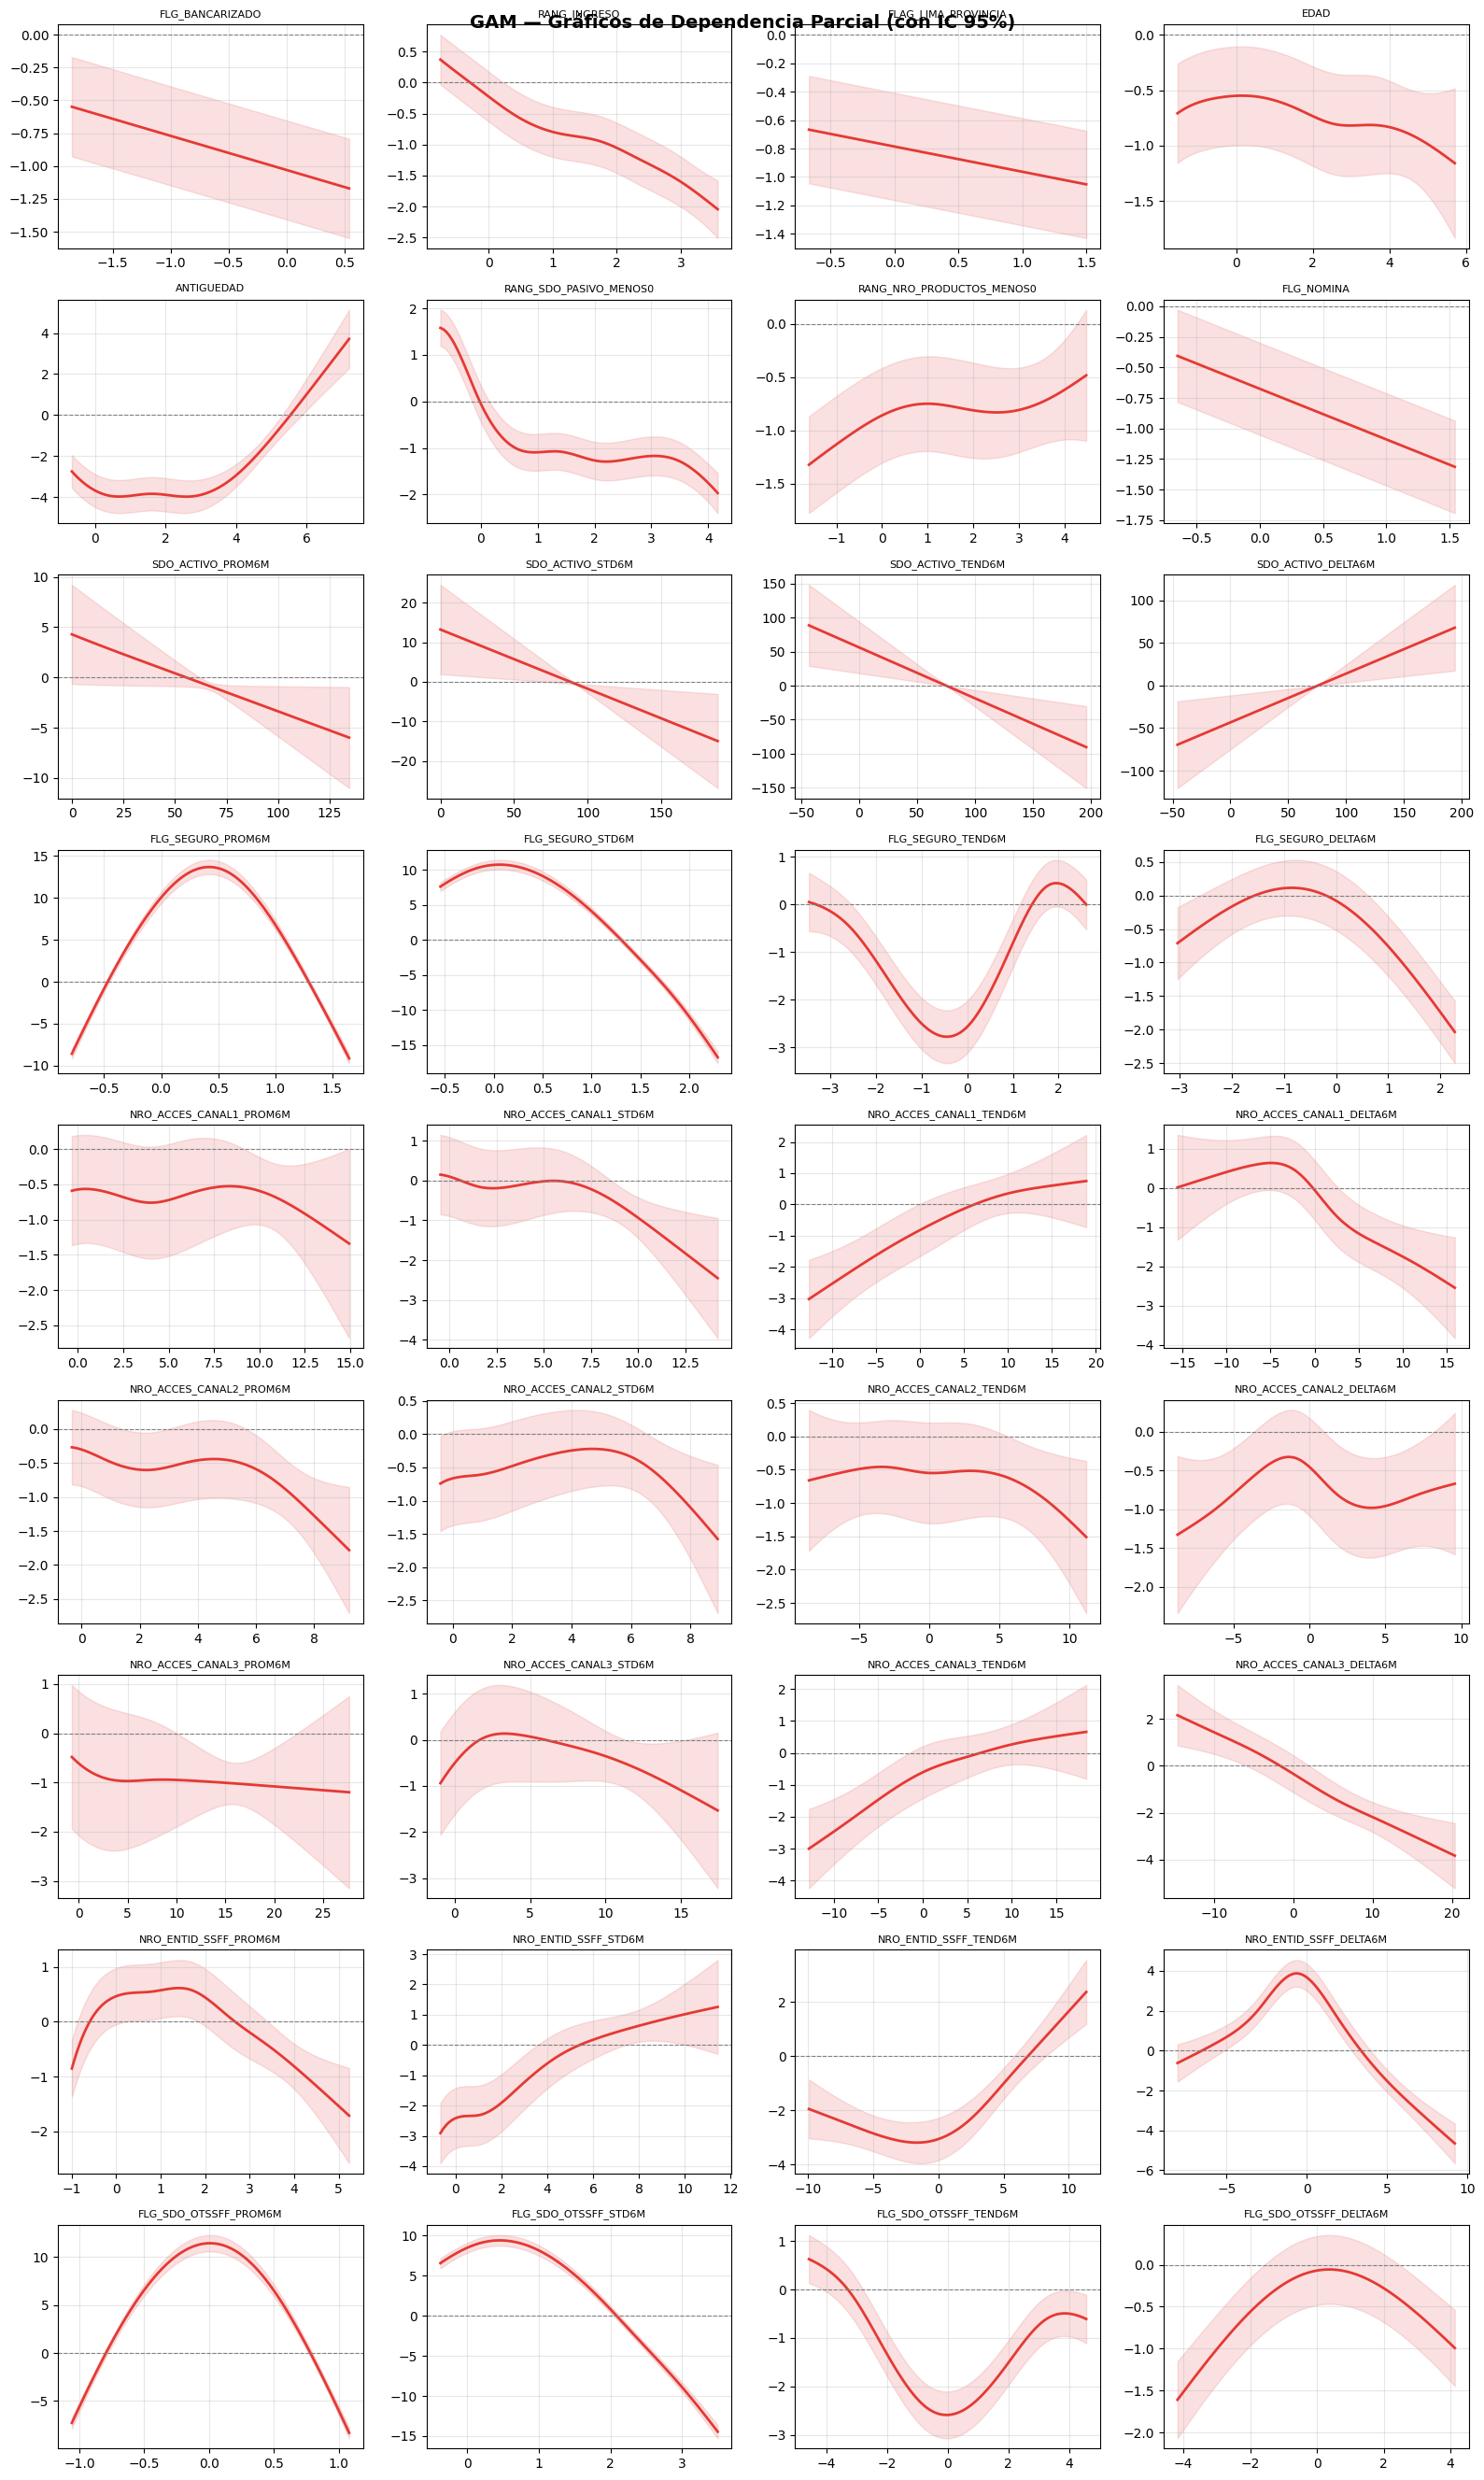

📊 Gráfico guardado: 03_gam_partial_dependence.png


In [12]:

# ==============================================================================
# BLOQUE 10 — MODELO GAM (Generalized Additive Model)
# ------------------------------------------------------------------------------
# Usamos LogisticGAM de la librería pygam (clasificación binaria).
# Cada variable tiene un término suavizado s() (spline cúbico) con n_splines=10.
# El parámetro lam controla el grado de suavizado; lo optimizamos con gridsearch.
#
# Interpretación del GAM:
#   g(E[Y]) = β₀ + f₁(x₁) + f₂(x₂) + ... + fₚ(xₚ)
#   Donde g es el logit y cada fᵢ es una función suave no lineal.
# ==============================================================================

print("\n🔧 Entrenando modelo GAM...")

# Construcción dinámica de los términos del modelo
# s(i) = spline suavizado para la variable en posición i
terms_gam = s(0)
for i in range(1, len(vars_gam)):
    terms_gam += s(i)

gam_model = LogisticGAM(terms_gam, n_splines=10)

# Búsqueda del mejor parámetro de regularización (lam) con cross-validation
# lam controla la suavidad: valores altos → más liso (más bias, menos varianza)
print("   Optimizando hiperparámetro lam (regularización)...")
gam_model.gridsearch(X_train_gam, y_train_bal, progress=True)

print(f"✅ GAM entrenado | lam óptimo: {gam_model.lam}")

# Predicción de probabilidades en test
y_prob_gam_train = gam_model.predict_proba(X_train_gam)
y_prob_gam_test  = gam_model.predict_proba(X_test_gam)

auc_gam_train = roc_auc_score(y_train_bal, y_prob_gam_train)
auc_gam_test  = roc_auc_score(y_test, y_prob_gam_test)

print(f"\n📈 GAM — AUC Train: {auc_gam_train:.4f}")
print(f"📈 GAM — AUC Test:  {auc_gam_test:.4f}")


# ==============================================================================
# BLOQUE 11 — GRÁFICOS DE DEPENDENCIA PARCIAL GAM
# ------------------------------------------------------------------------------
# Los gráficos de dependencia parcial (partial dependence plots) muestran
# cómo cambia la probabilidad de fuga cuando varía cada variable, manteniendo
# las demás constantes. Son el análogo del GAM a los coeficientes de regresión.
# La banda sombreada es el intervalo de confianza al 95%.
# ==============================================================================

n_vars = len(vars_gam)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, (term, var_name) in enumerate(zip(gam_model.terms, vars_gam)):
    XX = gam_model.generate_X_grid(term=i)
    pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep, color='#E53935', linewidth=2)
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                         alpha=0.3, color='#EF9A9A')
    axes[i].set_title(var_name, fontsize=8)
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].grid(True, alpha=0.3)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GAM — Gráficos de Dependencia Parcial (con IC 95%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("03_gam_partial_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 03_gam_partial_dependence.png")


In [13]:



# ==============================================================================
# BLOQUE 12 — MODELO LIGHTGBM
# ------------------------------------------------------------------------------
# LightGBM es un gradient boosting basado en árboles que:
#   - Aprende interacciones no lineales entre variables automáticamente
#   - Es eficiente con datasets medianos (~70K filas)
#   - Puede usar todos los lags individuales + features agregadas
# Usamos el conjunto COMPLETO de variables (no solo las agregadas del GAM).
#
# Hiperparámetros elegidos:
#   - n_estimators=500 con early stopping para evitar sobreajuste
#   - max_depth=6, num_leaves=31: control de complejidad del árbol
#   - learning_rate=0.05: tasa de aprendizaje conservadora
#   - scale_pos_weight: alternativa a SMOTE para manejar desbalance
# ==============================================================================

print("\n🔧 Entrenando modelo LightGBM...")

# Ratio para manejar desbalance (alternativa o complemento a SMOTE)
ratio = (y_train_bal == 0).sum() / (y_train_bal == 1).sum()

lgbm_model = LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=500,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # regularización L1
    reg_lambda=0.1,       # regularización L2
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Early stopping: detiene el entrenamiento si no mejora en 50 rondas
# Usamos parte del train como validación para el early stopping
X_tr_lgb, X_val_lgb, y_tr_lgb, y_val_lgb = train_test_split(
    X_train_bal, y_train_bal, test_size=0.15, random_state=42, stratify=y_train_bal
)

lgbm_model.fit(
    X_tr_lgb, y_tr_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f"✅ LightGBM entrenado | Árboles usados: {lgbm_model.best_iteration_}")

# Predicción de probabilidades
y_prob_lgbm_train = lgbm_model.predict_proba(X_train_bal)[:, 1]
y_prob_lgbm_test  = lgbm_model.predict_proba(X_test)[:, 1]

auc_lgbm_train = roc_auc_score(y_train_bal, y_prob_lgbm_train)
auc_lgbm_test  = roc_auc_score(y_test, y_prob_lgbm_test)

print(f"\n📈 LightGBM — AUC Train: {auc_lgbm_train:.4f}")
print(f"📈 LightGBM — AUC Test:  {auc_lgbm_test:.4f}")




🔧 Entrenando modelo LightGBM...
[100]	valid_0's binary_logloss: 0.304709
[200]	valid_0's binary_logloss: 0.258086
[300]	valid_0's binary_logloss: 0.239986
[400]	valid_0's binary_logloss: 0.228773
[500]	valid_0's binary_logloss: 0.223424
✅ LightGBM entrenado | Árboles usados: 500

📈 LightGBM — AUC Train: 0.9758
📈 LightGBM — AUC Test:  0.8210


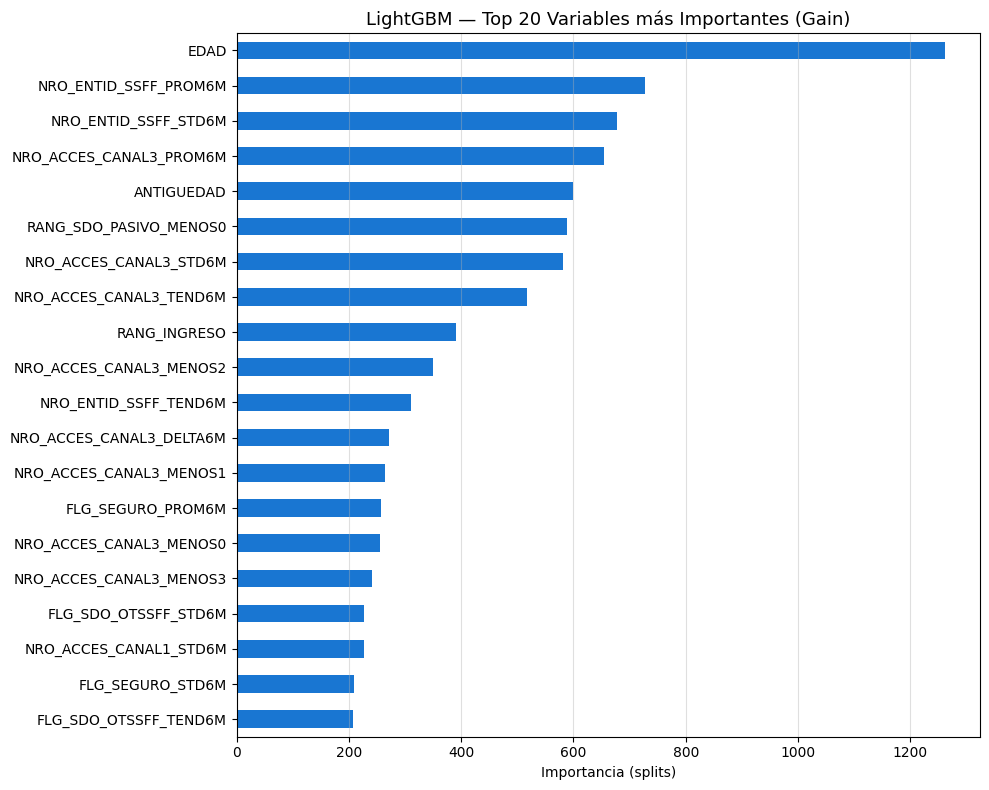

📊 Gráfico guardado: 04_lgbm_feature_importance.png

🔧 Calculando valores SHAP (puede tomar ~1-2 minutos)...


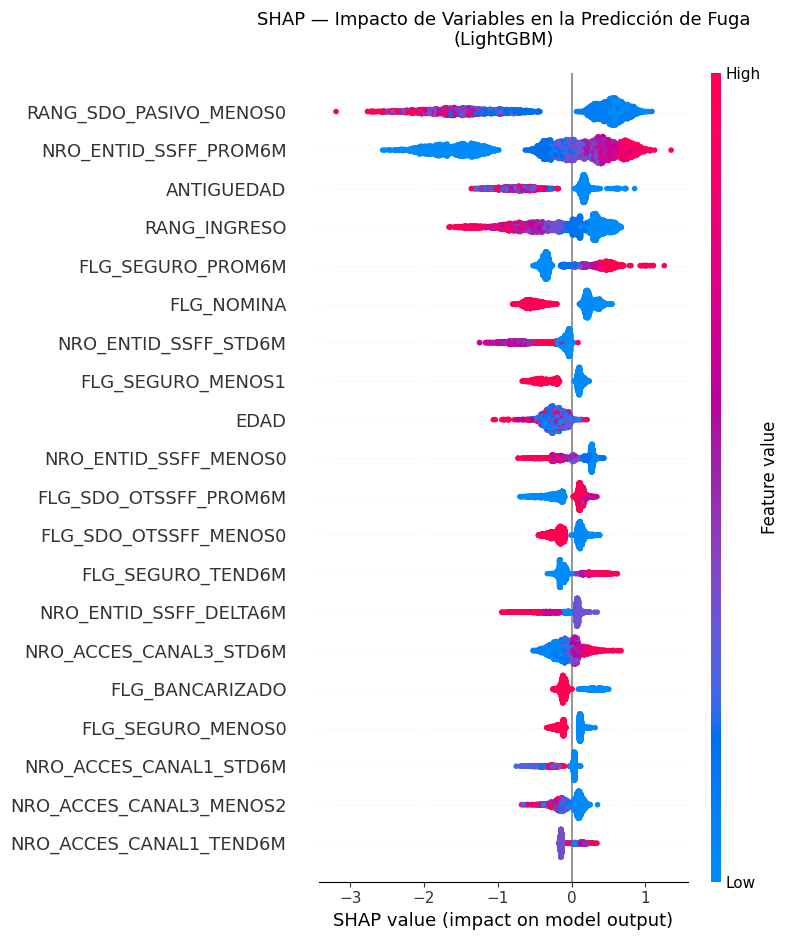

📊 Gráfico guardado: 05_shap_summary.png


<Figure size 800x500 with 0 Axes>

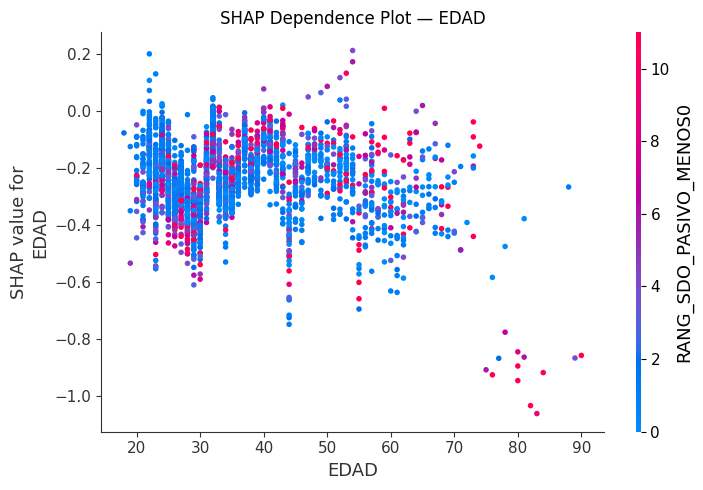

📊 Gráfico guardado: 06_shap_dependence.png


In [14]:

# ==============================================================================
# BLOQUE 13 — IMPORTANCIA DE VARIABLES (LightGBM)
# ------------------------------------------------------------------------------
# LightGBM provee dos métricas de importancia:
#   - 'split': número de veces que la variable fue usada en un split del árbol
#   - 'gain': ganancia total de información atribuida a la variable (más informativo)
# Mostramos las top 20 por 'gain'.
# ==============================================================================

feature_names = X_all.columns.tolist()
importances = pd.Series(lgbm_model.feature_importances_, index=feature_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#1976D2')
ax.set_title('LightGBM — Top 20 Variables más Importantes (Gain)', fontsize=13)
ax.set_xlabel('Importancia (splits)')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig("04_lgbm_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 04_lgbm_feature_importance.png")


# ==============================================================================
# BLOQUE 14 — VALORES SHAP (LightGBM)
# ------------------------------------------------------------------------------
# SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada
# variable a la predicción de cada cliente individual, basado en teoría de
# juegos cooperativos. A diferencia de la importancia global, SHAP muestra
# tanto la magnitud como la dirección del efecto.
#
# Tipos de gráficos:
#   - Summary plot: distribución de valores SHAP por variable (dirección + magnitud)
#   - Dependence plot: relación entre el valor de la variable y su impacto SHAP
# ==============================================================================

print("\n🔧 Calculando valores SHAP (puede tomar ~1-2 minutos)...")

# Usamos una muestra para eficiencia en Colab
sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap_sample = X_test.iloc[sample_idx] if hasattr(X_test, 'iloc') else X_test[sample_idx]

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap_sample)

# Si shap_values es lista [class0, class1], tomamos la clase 1 (fuga)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap_sample,
                  feature_names=feature_names, show=False, max_display=20)
plt.title('SHAP — Impacto de Variables en la Predicción de Fuga\n(LightGBM)',
          fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("05_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 05_shap_summary.png")

# Dependence plot para la variable más importante
top_var = importances.idxmax()
top_var_idx = feature_names.index(top_var)
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_var_idx, shap_vals, X_shap_sample,
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot — {top_var}', fontsize=12)
plt.tight_layout()
plt.savefig("06_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Gráfico guardado: 06_shap_dependence.png")


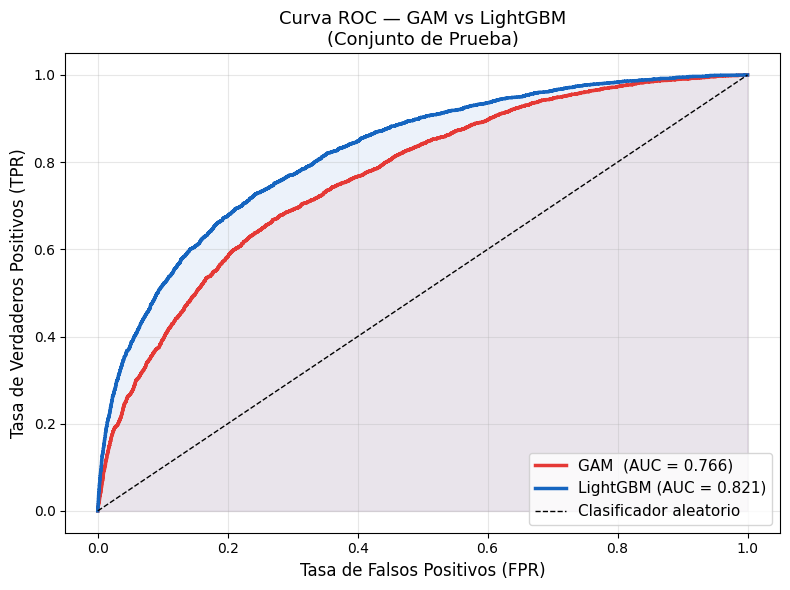

📊 Gráfico guardado: 07_roc_comparison.png


In [15]:


# ==============================================================================
# BLOQUE 15 — COMPARACIÓN DE CURVAS ROC
# ------------------------------------------------------------------------------
# La curva ROC muestra el trade-off entre sensibilidad (TPR) y especificidad
# (1-FPR) para todos los posibles umbrales de clasificación.
# El AUC (Area Under Curve) resume la capacidad discriminante en un solo número:
#   - AUC = 0.5: modelo sin información (equivale a clasificar al azar)
#   - AUC = 1.0: clasificador perfecto
# Comparamos ambos modelos sobre el mismo conjunto de prueba.
# ==============================================================================

fpr_gam, tpr_gam, _ = roc_curve(y_test, y_prob_gam_test)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_gam, tpr_gam, color='#E53935', linewidth=2.5,
        label=f'GAM  (AUC = {auc_gam_test:.3f})')
ax.plot(fpr_lgbm, tpr_lgbm, color='#1565C0', linewidth=2.5,
        label=f'LightGBM (AUC = {auc_lgbm_test:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.fill_between(fpr_gam, tpr_gam, alpha=0.08, color='#E53935')
ax.fill_between(fpr_lgbm, tpr_lgbm, alpha=0.08, color='#1565C0')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — GAM vs LightGBM\n(Conjunto de Prueba)', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("07_roc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 07_roc_comparison.png")




UMBRAL ÓPTIMO GAM:     0.369
UMBRAL ÓPTIMO LightGBM: 0.202

📋 REPORTE GAM:
              precision    recall  f1-score   support

     No Fuga       0.92      0.73      0.82     17753
        Fuga       0.31      0.67      0.43      3247

    accuracy                           0.72     21000
   macro avg       0.62      0.70      0.62     21000
weighted avg       0.83      0.72      0.76     21000


📋 REPORTE LightGBM:
              precision    recall  f1-score   support

     No Fuga       0.94      0.76      0.84     17753
        Fuga       0.35      0.73      0.48      3247

    accuracy                           0.75     21000
   macro avg       0.65      0.74      0.66     21000
weighted avg       0.85      0.75      0.78     21000



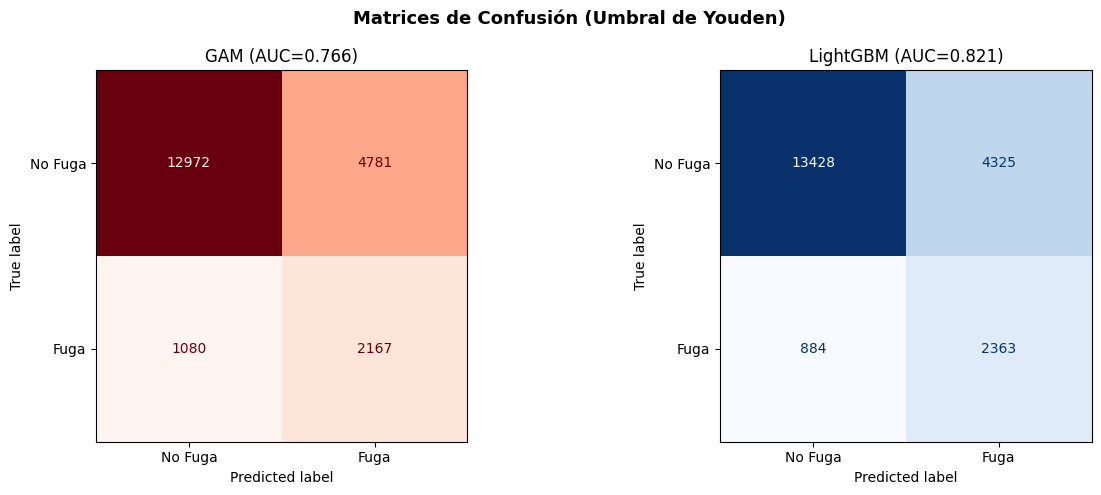

📊 Gráfico guardado: 08_confusion_matrices.png


In [16]:

# ==============================================================================
# BLOQUE 16 — MÉTRICAS DE CLASIFICACIÓN
# ------------------------------------------------------------------------------
# Umbral óptimo: usamos el punto que maximiza el índice de Youden (TPR - FPR),
# que es el umbral que mejor balancea sensibilidad y especificidad.
#
# Métricas reportadas:
#   - Precision: de los que el modelo predice como "fuga", ¿cuántos realmente fugaron?
#   - Recall (Sensibilidad): de los clientes que fugaron, ¿cuántos detectó el modelo?
#   - F1-Score: media armónica entre precision y recall
#   - AUC-ROC: capacidad discriminante global
# ==============================================================================

def umbral_youden(fpr, tpr, thresholds):
    """Retorna el umbral que maximiza la diferencia TPR - FPR (Youden)."""
    idx = np.argmax(tpr - fpr)
    return thresholds[idx]

fpr_g, tpr_g, thr_g = roc_curve(y_test, y_prob_gam_test)
fpr_l, tpr_l, thr_l = roc_curve(y_test, y_prob_lgbm_test)

umb_gam  = umbral_youden(fpr_g, tpr_g, thr_g)
umb_lgbm = umbral_youden(fpr_l, tpr_l, thr_l)

y_pred_gam  = (y_prob_gam_test  >= umb_gam).astype(int)
y_pred_lgbm = (y_prob_lgbm_test >= umb_lgbm).astype(int)

print("\n" + "="*60)
print(f"UMBRAL ÓPTIMO GAM:     {umb_gam:.3f}")
print(f"UMBRAL ÓPTIMO LightGBM: {umb_lgbm:.3f}")
print("="*60)

print("\n📋 REPORTE GAM:")
print(classification_report(y_test, y_pred_gam, target_names=['No Fuga', 'Fuga']))

print("\n📋 REPORTE LightGBM:")
print(classification_report(y_test, y_pred_lgbm, target_names=['No Fuga', 'Fuga']))

# Matrices de confusión comparadas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, titulo, modelo in [
    (axes[0], y_pred_gam, f'GAM (AUC={auc_gam_test:.3f})', 'Reds'),
    (axes[1], y_pred_lgbm, f'LightGBM (AUC={auc_lgbm_test:.3f})', 'Blues')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fuga', 'Fuga'])
    disp.plot(ax=ax, colorbar=False, cmap=modelo)
    ax.set_title(titulo, fontsize=12)
plt.suptitle('Matrices de Confusión (Umbral de Youden)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("08_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 08_confusion_matrices.png")



In [17]:

# ==============================================================================
# BLOQUE 17 — VALIDACIÓN CRUZADA (CROSS-VALIDATION)
# ------------------------------------------------------------------------------
# La validación cruzada estratificada con k=5 pliegues estima el desempeño
# real del modelo en datos no vistos, reduciendo la varianza de la estimación
# respecto a un único split. Comparamos los AUC promedio de ambos modelos.
# NOTA: Se ejecuta sobre el conjunto de entrenamiento completo (sin SMOTE
# aplicado previamente, para una estimación más realista).
# ==============================================================================

print("\n🔧 Validación cruzada (5 folds) — puede tomar unos minutos...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LightGBM CV (rápido)
cv_lgbm = cross_val_score(
    LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                   random_state=42, n_jobs=-1, verbose=-1),
    X_train_full, y_train_full,
    cv=skf, scoring='roc_auc', n_jobs=-1
)
print(f"LightGBM CV AUC: {cv_lgbm.mean():.4f} ± {cv_lgbm.std():.4f}")

# GAM CV (nota: más lento por el gridsearch interno; se puede saltar en Colab lento)
# Si tarda demasiado, comentar el bloque GAM CV
print("\n   GAM CV (puede ser lento — comentar si tarda demasiado)...")
cv_gam_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full[vars_gam], y_train_full)):
    X_f_train = scaler.fit_transform(X_train_full[vars_gam].iloc[train_idx])
    X_f_val   = scaler.transform(X_train_full[vars_gam].iloc[val_idx])
    y_f_train = y_train_full.iloc[train_idx]
    y_f_val   = y_train_full.iloc[val_idx]
    gam_cv = LogisticGAM(terms_gam, n_splines=10)
    gam_cv.fit(X_f_train, y_f_train)
    auc_f = roc_auc_score(y_f_val, gam_cv.predict_proba(X_f_val))
    cv_gam_scores.append(auc_f)
    print(f"   Fold {fold+1}: AUC = {auc_f:.4f}")

cv_gam = np.array(cv_gam_scores)
print(f"GAM CV AUC: {cv_gam.mean():.4f} ± {cv_gam.std():.4f}")




🔧 Validación cruzada (5 folds) — puede tomar unos minutos...
LightGBM CV AUC: 0.8376 ± 0.0055

   GAM CV (puede ser lento — comentar si tarda demasiado)...
   Fold 1: AUC = 0.8039
   Fold 2: AUC = 0.8046
   Fold 3: AUC = 0.7942
   Fold 4: AUC = 0.7973
   Fold 5: AUC = 0.7949
GAM CV AUC: 0.7990 ± 0.0044


In [18]:

# ==============================================================================
# BLOQUE 18 — TABLA RESUMEN COMPARATIVA
# ------------------------------------------------------------------------------
# Consolidamos las métricas clave de ambos modelos en una tabla para facilitar
# la comparación y la toma de decisiones sobre cuál modelo usar en producción.
# ==============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['GAM', 'LightGBM'],
    'AUC Train': [round(auc_gam_train, 4), round(auc_lgbm_train, 4)],
    'AUC Test': [round(auc_gam_test, 4), round(auc_lgbm_test, 4)],
    'AUC CV (mean)': [round(cv_gam.mean(), 4), round(cv_lgbm.mean(), 4)],
    'AUC CV (std)': [round(cv_gam.std(), 4), round(cv_lgbm.std(), 4)],
    'Precision (Fuga)': [
        round(precision_score(y_test, y_pred_gam), 4),
        round(precision_score(y_test, y_pred_lgbm), 4)
    ],
    'Recall (Fuga)': [
        round(recall_score(y_test, y_pred_gam), 4),
        round(recall_score(y_test, y_pred_lgbm), 4)
    ],
    'F1 (Fuga)': [
        round(f1_score(y_test, y_pred_gam), 4),
        round(f1_score(y_test, y_pred_lgbm), 4)
    ],
    'Interpretabilidad': ['Alta (splines)', 'Media (SHAP)'],
    'Velocidad entrenamiento': ['Lenta', 'Rápida'],
    'Manejo de interacciones': ['No (aditivo)', 'Sí (árboles)'],
})

print("\n" + "="*80)
print("TABLA COMPARATIVA FINAL: GAM vs LightGBM")
print("="*80)
print(resultados.to_string(index=False))

# Guardar como CSV
resultados.to_csv("tabla_comparativa_modelos.csv", index=False)
print("\n✅ Tabla guardada: tabla_comparativa_modelos.csv")




TABLA COMPARATIVA FINAL: GAM vs LightGBM
  Modelo  AUC Train  AUC Test  AUC CV (mean)  AUC CV (std)  Precision (Fuga)  Recall (Fuga)  F1 (Fuga) Interpretabilidad Velocidad entrenamiento Manejo de interacciones
     GAM     0.9166    0.7658         0.7990        0.0044            0.3119         0.6674     0.4251    Alta (splines)                   Lenta            No (aditivo)
LightGBM     0.9758    0.8210         0.8376        0.0055            0.3533         0.7277     0.4757      Media (SHAP)                  Rápida            Sí (árboles)

✅ Tabla guardada: tabla_comparativa_modelos.csv


In [19]:

# ==============================================================================
# BLOQUE 19 — SCORING: PROBABILIDAD DE FUGA POR CLIENTE
# ------------------------------------------------------------------------------
# Generamos una tabla con la probabilidad de fuga estimada por LightGBM
# para cada cliente del conjunto de prueba. Esto es el output operacional
# del modelo: permite al banco priorizar acciones de retención.
# ==============================================================================

df_scoring = X_test.copy() if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test, columns=feature_names)
df_scoring['ID_CORRELATIVO'] = df.loc[y_test.index, 'ID_CORRELATIVO'].values
df_scoring['ATTRITION_REAL'] = y_test.values
df_scoring['PROB_FUGA_LGBM'] = y_prob_lgbm_test
df_scoring['PROB_FUGA_GAM'] = y_prob_gam_test
df_scoring['SCORE_DECIL'] = pd.qcut(df_scoring['PROB_FUGA_LGBM'], q=10,
                                     labels=[f'D{i}' for i in range(1, 11)])

# Top 20 clientes en mayor riesgo
top_riesgo = df_scoring.sort_values('PROB_FUGA_LGBM', ascending=False).head(20)[
    ['ID_CORRELATIVO', 'PROB_FUGA_LGBM', 'PROB_FUGA_GAM', 'ATTRITION_REAL', 'SCORE_DECIL']
]
print("\n🎯 TOP 20 clientes con mayor probabilidad de fuga (LightGBM):")
print(top_riesgo.to_string(index=False))

# Guardar scoring completo
df_scoring[['ID_CORRELATIVO', 'PROB_FUGA_LGBM', 'PROB_FUGA_GAM',
            'ATTRITION_REAL', 'SCORE_DECIL']].to_csv("scoring_clientes.csv", index=False)
print("\n✅ Scoring guardado: scoring_clientes.csv")




🎯 TOP 20 clientes con mayor probabilidad de fuga (LightGBM):
 ID_CORRELATIVO  PROB_FUGA_LGBM  PROB_FUGA_GAM  ATTRITION_REAL SCORE_DECIL
          29232        0.960470       0.782333               1         D10
          12501        0.953117       0.826027               1         D10
          16737        0.950544       0.393902               1         D10
          11011        0.947039       0.908394               1         D10
          25532        0.946126       0.770519               1         D10
           4581        0.945237       0.876634               1         D10
          79291        0.945058       0.774433               1         D10
          97215        0.942765       0.834270               1         D10
          82572        0.941139       0.854401               1         D10
          72110        0.940852       0.849169               1         D10
          94183        0.940299       0.879128               1         D10
          13342        0.938776       


📊 Análisis por decil (LightGBM):
SCORE_DECIL  n_clientes  n_fugados  tasa_fuga     lift
        D10        2100       1221   0.581429 3.760394
         D9        2100        663   0.315714 2.041885
         D8        2100        408   0.194286 1.256545
         D7        2100        284   0.135238 0.874654
         D6        2100        250   0.119048 0.769941
         D5        2100        153   0.072857 0.471204
         D4        2100        108   0.051429 0.332615
         D3        2100         92   0.043810 0.283338
         D2        2100         44   0.020952 0.135510
         D1        2100         24   0.011429 0.073914


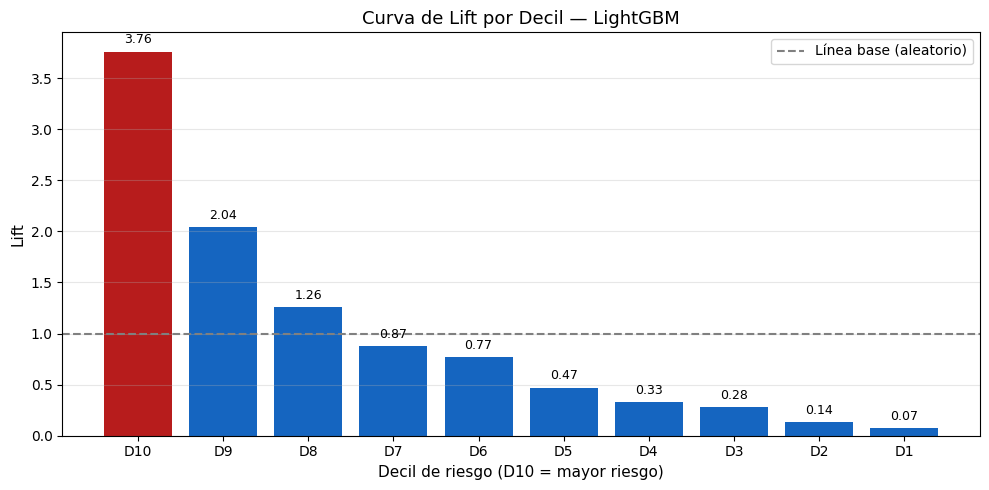

📊 Gráfico guardado: 09_lift_deciles.png


In [20]:

# ==============================================================================
# BLOQUE 20 — ANÁLISIS POR DECIL (LIFT CURVE)
# ------------------------------------------------------------------------------
# La curva de lift muestra cuántas veces más efectivo es el modelo frente a
# una selección aleatoria. Por ejemplo, un lift de 3 en el decil 1 significa
# que si contactamos al 10% de mayor riesgo predicho, encontraremos 3 veces
# más fugados que si elegiríamos clientes al azar.
# ==============================================================================

decil_analysis = df_scoring.groupby('SCORE_DECIL').agg(
    n_clientes=('ATTRITION_REAL', 'count'),
    n_fugados=('ATTRITION_REAL', 'sum'),
    prob_fuga_media=('PROB_FUGA_LGBM', 'mean')
).reset_index()
decil_analysis['tasa_fuga'] = decil_analysis['n_fugados'] / decil_analysis['n_clientes']
tasa_global = y_test.mean()
decil_analysis['lift'] = decil_analysis['tasa_fuga'] / tasa_global
decil_analysis = decil_analysis.sort_values('SCORE_DECIL', ascending=False)

print("\n📊 Análisis por decil (LightGBM):")
print(decil_analysis[['SCORE_DECIL', 'n_clientes', 'n_fugados',
                        'tasa_fuga', 'lift']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#B71C1C' if d == 'D10' else '#1565C0' for d in decil_analysis['SCORE_DECIL']]
bars = ax.bar(decil_analysis['SCORE_DECIL'], decil_analysis['lift'], color=colors)
ax.axhline(1, color='gray', linestyle='--', linewidth=1.5, label='Línea base (aleatorio)')
ax.set_xlabel('Decil de riesgo (D10 = mayor riesgo)', fontsize=11)
ax.set_ylabel('Lift', fontsize=11)
ax.set_title('Curva de Lift por Decil — LightGBM', fontsize=13)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, decil_analysis['lift']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("09_lift_deciles.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico guardado: 09_lift_deciles.png")



In [21]:

# ==============================================================================
# RESUMEN FINAL
# ==============================================================================

print("\n" + "="*70)
print("RESUMEN DE LO REALIZADO")
print("="*70)
print("""
1. CARGA Y EDA
   - 70,000 registros, 53 variables originales
   - Target ATTRITION: 15.5% de fuga (desbalance moderado)
   - Variables temporales: 7 grupos × 6 lags (MENOS0 a MENOS5)

2. INGENIERÍA DE FEATURES TEMPORALES
   - Creadas 4 features por cada uno de los 7 grupos temporales:
     * PROM6M: promedio de los 6 meses
     * STD6M: variabilidad/estabilidad
     * TEND6M: pendiente de regresión lineal (¿sube o baja?)
     * DELTA6M: diferencia entre mes actual y hace 6 meses
   - Total: 28 nuevas features que resumen el comportamiento temporal

3. PREPROCESAMIENTO
   - Imputación: mediana para numéricas, moda para categóricas
   - Label Encoding para variables ordinales categóricas
   - SMOTE en train para balancear clases
   - StandardScaler (requerido por GAM)

4. MODELO GAM (LogisticGAM — pygam)
   - Variables: 8 estáticas + 28 features temporales agregadas (36 total)
   - Término s() (spline cúbico) por variable
   - Hiperparámetro lam optimizado con gridsearch interno
   - Interpretación mediante gráficos de dependencia parcial por variable

5. MODELO LIGHTGBM
   - Variables: todas (53 originales + 28 agregadas = 81 features)
   - Early stopping sobre 15% del train como validación interna
   - Interpretabilidad complementada con valores SHAP

6. COMPARACIÓN
   - Curvas ROC y AUC en train/test para ambos modelos
   - Validación cruzada estratificada (5 folds)
   - Métricas con umbral óptimo de Youden
   - Análisis de lift por decil

7. SALIDAS OPERACIONALES
   - tabla_comparativa_modelos.csv: métricas comparativas
   - scoring_clientes.csv: probabilidad de fuga por cliente + decil
""")


RESUMEN DE LO REALIZADO

1. CARGA Y EDA
   - 70,000 registros, 53 variables originales
   - Target ATTRITION: 15.5% de fuga (desbalance moderado)
   - Variables temporales: 7 grupos × 6 lags (MENOS0 a MENOS5)

2. INGENIERÍA DE FEATURES TEMPORALES
   - Creadas 4 features por cada uno de los 7 grupos temporales:
     * PROM6M: promedio de los 6 meses
     * STD6M: variabilidad/estabilidad
     * TEND6M: pendiente de regresión lineal (¿sube o baja?)
     * DELTA6M: diferencia entre mes actual y hace 6 meses
   - Total: 28 nuevas features que resumen el comportamiento temporal

3. PREPROCESAMIENTO
   - Imputación: mediana para numéricas, moda para categóricas
   - Label Encoding para variables ordinales categóricas
   - SMOTE en train para balancear clases
   - StandardScaler (requerido por GAM)

4. MODELO GAM (LogisticGAM — pygam)
   - Variables: 8 estáticas + 28 features temporales agregadas (36 total)
   - Término s() (spline cúbico) por variable
   - Hiperparámetro lam optimizado con 